#### llenar_faltantes.ipynb

In [12]:
import pandas as pd
df = pd.read_csv('GLT_filtrado.csv')
datos_faltantes =df['AverageTemperature'].isna().sum()
print(datos_faltantes)

27581


In [13]:
porcentaje = (datos_faltantes / len(df['AverageTemperature']))*100
print (f" El porcentaje de datos faltantes es : {porcentaje} %")

 El porcentaje de datos faltantes es : 12.561083912102927 %


In [14]:
import numpy as np

def llenar_faltantes(lista):
    # Convertir la lista a un array de NumPy, reemplazando '' con NaN
    datos = np.array([float(x) if x != '' else np.nan for x in lista])

    # Recorrer todos los elementos de la lista
    for i in range(len(datos)):
        if np.isnan(datos[i]):  # Si el valor es NaN (antes era '')
            # Buscar el valor anterior más cercano
            previo = 0
            for j in range(i-1, -1, -1):  #aqui estamos llendo hacia atras recuerda (inicio , final , de cuanto en cuanto)
                if not np.isnan(datos[j]):
                    previo = datos[j]
                    break

            # Buscar el valor siguiente más cercano
            siguiente = 0
            for j in range(i+1, len(datos)):
                if not np.isnan(datos[j]):
                    siguiente = datos[j]
                    break

            # Reemplazar NaN con la media de los vecinos más cercanos
            datos[i] = (previo + siguiente) / 2

    return datos.tolist()  # Convertir el array de NumPy de vuelta a lista

In [15]:
df_copia = df.copy()

# guardar las primeras 10 filas ANTES
antes_rellenar = df_copia[df_copia['AverageTemperature'].isna()].head(10).copy()
print("ANTES de rellenar valores faltantes:")
print(antes_rellenar[['City', 'AverageTemperature']])

# orden
df_copia = df_copia.sort_values(['City', 'Date']) ## ordenamos temporalmente, para que tenga sentido el anterior y despues 

# aplicar la función
for ciudad in df_copia['City'].unique():  #unique obtiene valores diferentes sin repetirlos , basicamente para cada ciudad diferente
    indice_ciudad = df_copia['City'] == ciudad
    temperaturas = df_copia.loc[indice_ciudad, 'AverageTemperature'].tolist() #seleccionamos la ciudad y obtenemos solo  la temperatura, los pasa a una lista 
    temperaturas_rellenadas = llenar_faltantes(temperaturas)
    df_copia.loc[indice_ciudad, 'AverageTemperature'] = temperaturas_rellenadas

# DESPUÉS de rellenaR
despues_rellenar = df_copia.loc[antes_rellenar.index]
print("\nDESPUÉS de rellenar valores faltantes:")
print(despues_rellenar[['City', 'AverageTemperature']])

ANTES de rellenar valores faltantes:
       City  AverageTemperature
2   Abidjan                 NaN
8   Abidjan                 NaN
23  Abidjan                 NaN
24  Abidjan                 NaN
28  Abidjan                 NaN
34  Abidjan                 NaN
36  Abidjan                 NaN
37  Abidjan                 NaN
38  Abidjan                 NaN
39  Abidjan                 NaN

DESPUÉS de rellenar valores faltantes:
       City  AverageTemperature
2   Abidjan           26.787000
8   Abidjan           24.419500
23  Abidjan           26.452500
24  Abidjan           26.907750
28  Abidjan           25.751000
34  Abidjan           25.670500
36  Abidjan           26.446000
37  Abidjan           26.567500
38  Abidjan           26.628250
39  Abidjan           26.658625


## 6 Tarea

#### 1. Hay una anomalia en la distribucion de datos. Con ayuda de Matplotlib y el metodo IQR, detecta la anomalia. Para ello, realiza los siguientes pasos: 1) Haz una grafica de la distribucion global de AverageTemperature usando un histograma. Observas una cola anormal o valores extremadamente grandes? 

In [17]:
print(datos.columns)

Index(['Date', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City',
       'Country', 'Latitude', 'Longitude'],
      dtype='str')


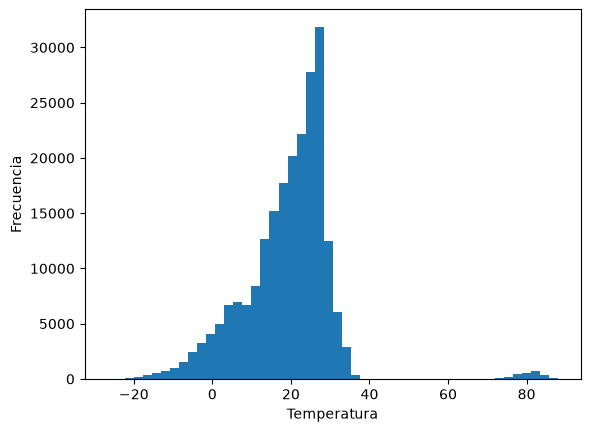

In [37]:
import matplotlib.pyplot as plt
datos=df_copia.copy()
plt.figure()
plt.hist(datos['AverageTemperature'], bins=50)
plt.xlabel('Temperatura')
plt.ylabel('Frecuencia')
plt.show()

La mayoria de los datos se miran centrado entre el 0 y 40 , observamos datos menores a 0 pero se comportan como una distribucion. Pero tambien notamos temperaturas mas grandes , lo que parece no ser normal , pues la diferencia seria de 50 grados, los cuales pueden considerarse como outliers

#### Calcula los lımites usando el metodo IQR y identifica todos los valores fuera de esos lımites. Determina que ciudad X genera lamayorıa de esos outliers.

In [38]:
## Calculamos los limites.
Q1 = df_copia['AverageTemperature'].quantile(0.25)
Q3 = df_copia['AverageTemperature'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + (1.5 * IQR)
limite_inferior = Q1 - (1.5 * IQR)

print("Limite superior: ", limite_superior)
print("Limite infeior: ", limite_inferior)

Limite superior:  44.753499999999995
Limite infeior:  -5.002499999999996


In [39]:
#Cuantos outliers hay , segun los limites que calculamos 
     ### Estamos guardando las filas donde la temperatura se sale de los limites
outliers = df_copia[
    (df_copia['AverageTemperature'] < limite_inferior) |
    (df_copia['AverageTemperature'] > limite_superior)
]
print("Cantidad de outliers:", len(outliers))

Cantidad de outliers: 7793


In [40]:
# Las ciudades con mas outliers , usamo .value_counts que cuenta cuantas veces se repite el valor, en este caso por ciudad
conteo_ciudades = outliers['City'].value_counts()
print(conteo_ciudades.head(10))

City
Bangkok             2352
Harbin               798
Changchun            684
Montreal             639
Moscow               578
Shenyang             524
Toronto              457
Saint Petersburg     424
Taiyuan              414
Kiev                 273
Name: count, dtype: int64


In [34]:
print("Ciudad con más outliers:", conteo_ciudades.index[0])

Ciudad con más outliers: Bangkok


#### 2. Como puedes ver, la ciudad X tiene distribuciones de temperatura muy diferentes. Sin embargo, lo que resulta extrano es la gran diferencia en la magnitud de sus temperaturas. Es posible que todos los sensores de las estaciones estuvieran defectuosos? Que crees que pudo haber sucedido aqui? Usa tu creatividad para analizarlo y proponer una explicacion.

In [51]:
df_copia[df_copia['City'] == 'Bangkok']['AverageTemperature'].describe()

count    2352.000000
mean       80.727179
std         3.045400
min        71.409200
25%        78.458450
50%        81.258800
75%        82.881500
max        88.007000
Name: AverageTemperature, dtype: float64

Notamos que que su media de temperatura es 80 y su desviacion estandar para esa ciudad es aceptable , es decir que la mediciones solo para esa ciudad parecen tener sentido, pero si la comparamos con las demas ciudades notamos como es demasiada la diferencia. Como hablamos de una medicion siempre es necesario aclarar en que unidades se realiza esa medición. Como hablamos de temperatura suponemos que hablamos de celsius , por lo que para la mayoria de ciudad esto tendria sentido, pero para Bangkok una lectura de 89 grados celsius suena muy ilogico. 
Si suponemos que todas las mediciones son Fahrenheit esto tendria sentido para Bangkok , pero para las demas ciudades esta implica climas muy frios , lo cual tampoco tiene sentido. 
Por lo que sugerimos que las medidas tomadas en Bangkok se realizaron en Farenheit mientras que en las demas ciudades se realizaron en Celsius.  

#### 3.Calcula la temperatura media anual para las siguientes ciudades: Roma, New York, Bangkok, Tokyo, Paris, Lima, Cairo, Moscow, Peking, Mexico. Observas algun incremento a lo largo de todo el tiempo de medicion? Defiende tu respuesta con graficas. Y si ahora divides los datos en periodos de 5, 10, 25 anos y observas como han cambiado las temperaturas medias en esos periodos? En cual de estas ciudades el cambio climatico ha sido mas pronunciado desde el siglo XIX?

In [65]:
## Creamos una lista con nuestras ciudades 
ciudades = ['Rome','New York','Bangkok','Tokyo','Paris','Lima','Cairo','Moscow','Peking','Mexico']

datos = df_copia[df_copia['City'].isin(ciudades)].copy() # # usamos .isin()  que verifica si city esta en la lista ciudades

datos['Date'] = pd.to_datetime(datos['Date']) # Le damos formato de fecha
datos['Year'] = datos['Date'].dt.year # Agregamos la columna de año 

# Como habiamos supuesto que Bangkok esta en farenheit lo pasamos a celsius
## datos.loc seleccionamos las filas con Bangkok,  y la columna de temperatura , y la definimos , y la convertimos a celsius
    ###esto para que cuando grafiquemos no se vea raro , y no se vea como cuando hicimos el punto 1. 

datos.loc[datos['City'] == 'Bangkok', 'AverageTemperature'] = (datos.loc[datos['City'] == 'Bangkok', 'AverageTemperature'] - 32) * (5 / 9)

##Verifico que se haya hecho la conversion.
print(datos.loc[datos['City'] == 'Bangkok', ['City', 'AverageTemperature']].head())


          City  AverageTemperature
18012  Bangkok              23.990
18013  Bangkok              26.786
18014  Bangkok              27.898
18015  Bangkok              29.126
18016  Bangkok              27.386


In [68]:
### Temperatura media anual
 ## estamos agrupando por ciudad y por año, y seleccionamos la temperatura y promediamos, con reset_index la volvemos a dejar como 2 columnas 
media_anual = datos.groupby(['City', 'Year'])['AverageTemperature'].mean().reset_index()
print(media_anual)

         City  Year  AverageTemperature
0     Bangkok  1817           25.896917
1     Bangkok  1818           26.510333
2     Bangkok  1819           25.891458
3     Bangkok  1820           26.208125
4     Bangkok  1821           26.809333
...       ...   ...                 ...
1842    Tokyo  2008           13.268833
1843    Tokyo  2009           13.360500
1844    Tokyo  2010           13.820500
1845    Tokyo  2011           13.577875
1846    Tokyo  2012           13.393854

[1847 rows x 3 columns]


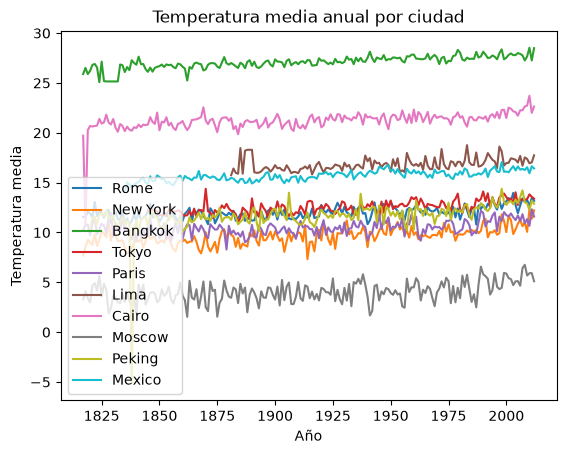

In [70]:
plt.figure()
##hacemos un plot para cada una de las ciudades con los promedios calculados en la parte anterior
for ciudad in ciudades:
    ciudad_datos = media_anual[media_anual['City'] == ciudad] #filtramos las ciudades
    plt.plot(ciudad_datos['Year'],ciudad_datos['AverageTemperature'],label=ciudad) #seleccionamos los x, y 
    
plt.xlabel('Año')
plt.ylabel('Temperatura media')
plt.title('Temperatura media anual por ciudad')
plt.legend()
plt.show()

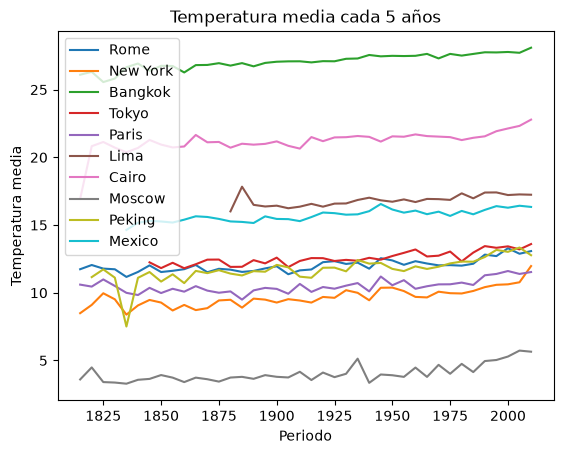

In [71]:
## Cada 5 años
 ## Creamos una columna la cual es la media anual cada 5 años
 ## esto usando la division entera asi cualquiera con residuo , cae dentro del periodo de 5 años, por eso volvemos a multiplicar por 5
 ## esto hace que 5 años compartan un año
media_anual['Periodo_5'] = (media_anual['Year'] // 5) * 5
 #calculamos el promedio de temperatur en el periodo de 5 años.
    ##esto agrupando por ciudad y el periodo_5 ya que ahi se repite el año 5 veces por periodo.
media_5 = media_anual.groupby(['City', 'Periodo_5'])['AverageTemperature'].mean().reset_index()

## Graficamos plt.figure(figsize=(12, 7))

for ciudad in ciudades:
    # un plot para cada ciudad
    ciudad_datos = media_5[media_5['City'] == ciudad]
    plt.plot(ciudad_datos['Periodo_5'],ciudad_datos['AverageTemperature'],label=ciudad)

plt.xlabel('Periodo')
plt.ylabel('Temperatura media')
plt.title('Temperatura media cada 5 años')
plt.legend()
plt.show()


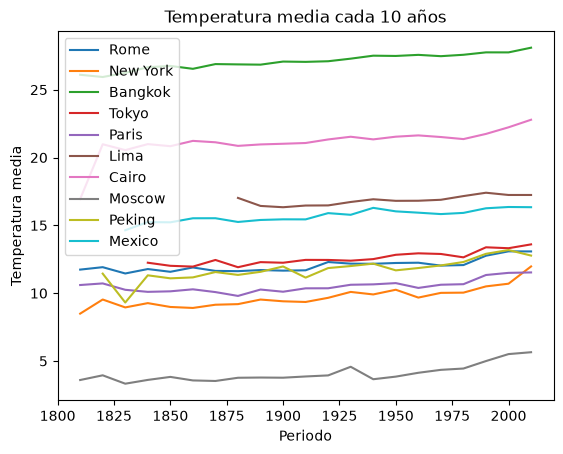

In [76]:
# Cada 10 años (analogo al periodo de cada 5 años)
media_anual['Periodo_10'] = (media_anual['Year'] // 10) * 10
media_10 = media_anual.groupby(['City', 'Periodo_10'])['AverageTemperature'].mean().reset_index()

plt.figure()
for ciudad in ciudades:
    ciudad_datos = media_10[media_10['City'] == ciudad]

    plt.plot(ciudad_datos['Periodo_10'],ciudad_datos['AverageTemperature'],label=ciudad)

plt.xlabel('Periodo')
plt.ylabel('Temperatura media')
plt.title('Temperatura media cada 10 años')
plt.legend()
plt.show()

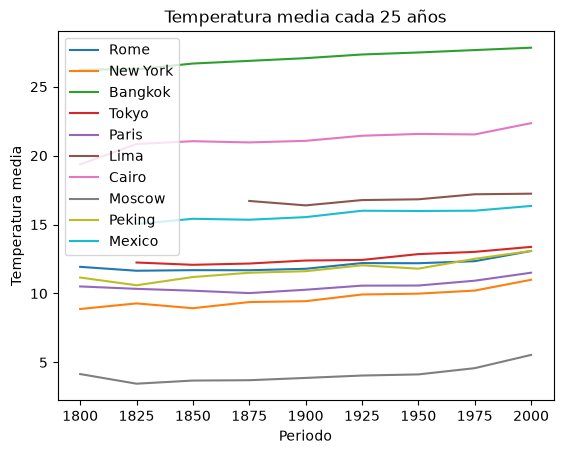

In [77]:
# Cada 25 años
media_anual['Periodo_25'] = (media_anual['Year'] // 25) * 25
media_25 = media_anual.groupby(['City', 'Periodo_25'])['AverageTemperature'].mean().reset_index()

plt.figure()

for ciudad in ciudades:
    ciudad_datos = media_25[media_25['City'] == ciudad]

    plt.plot(ciudad_datos['Periodo_25'],ciudad_datos['AverageTemperature'],label=ciudad)

plt.xlabel('Periodo')
plt.ylabel('Temperatura media')
plt.title('Temperatura media cada 25 años')
plt.legend()
plt.show()


Como observamos en las graficas , los cambios de temperatura no son constantes , pero si la dividimos en periodos estas se suavisan y observamos que quien tiene un incremento notorio es Peaking .